Model Evaluation Metrics:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        89
           1       0.91      0.86      0.89       111

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.88       200
weighted avg       0.88      0.88      0.88       200



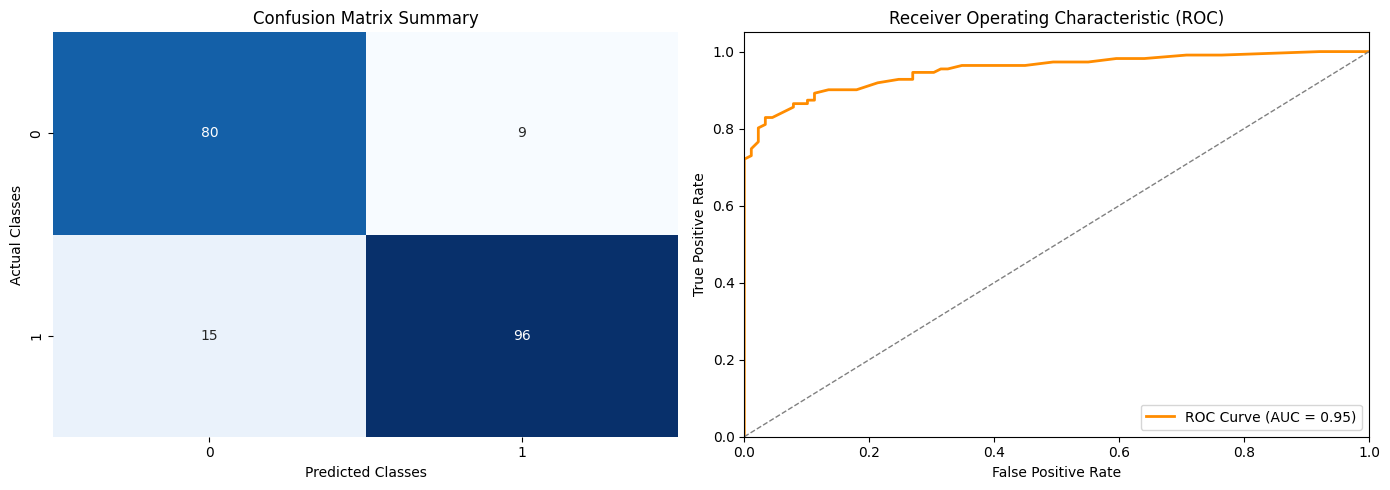

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.datasets import make_classification

# Load dataset
# X, y = make_classification(n_samples=1000, n_features=10, n_classes=2, random_state=42)

# If using a custom CSV file, uncomment the lines below:
# df = pd.read_csv('your_data.csv')
# X = df.drop(columns=['target_column'])
# y = df['target_column']

X, y = make_classification(n_samples=1000, n_features=10, n_classes=2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)

predictions = classifier.predict(X_test)
probabilities = classifier.predict_proba(X_test)[:, 1]

print("Model Evaluation Metrics:")
print(classification_report(y_test, predictions))

fig, axis = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axis[0])
axis[0].set_title('Confusion Matrix Summary')
axis[0].set_xlabel('Predicted Classes')
axis[0].set_ylabel('Actual Classes')

fpr, tpr, _ = roc_curve(y_test, probabilities)
roc_auc = auc(fpr, tpr)

axis[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
axis[1].plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--')
axis[1].set_xlim([0.0, 1.0])
axis[1].set_ylim([0.0, 1.05])
axis[1].set_title('Receiver Operating Characteristic (ROC)')
axis[1].set_xlabel('False Positive Rate')
axis[1].set_ylabel('True Positive Rate')
axis[1].legend(loc="lower right")

plt.tight_layout()
plt.show()